# 06-3. 주성분 분석

과일 이미지의 픽셀 특성 10000개를 더 적은 주성분으로 압축하고, 복원 품질·설명된 분산·분류 시간·군집 결과를 비교한다.

## 학습 목표

- 주성분이 데이터 분산이 큰 방향이라는 의미 이해
- 주성분에 투영해 특성 수를 줄이는 과정 이해
- `components_`, `explained_variance_ratio_` 해석
- 역변환으로 압축된 이미지 복원
- PCA 전후의 분류와 군집 결과 비교

## 1. 원본 이미지 데이터

과일 이미지 한 장은 `100×100=10000`개의 픽셀 특성으로 표현된다.

```text
샘플 수: 300
원본 특성 수: 10000
원본 데이터 크기: (300, 10000)
```

> **이전 질문과 연결 — “머신러닝에서 차원이 무엇인가?”**  
> 이 실습에서 차원은 이미지의 가로·세로 공간이 아니라 샘플 하나를 표현하는 특성 수다. 픽셀 10000개를 입력으로 사용하므로 원본 이미지는 10000차원 데이터다.

In [3]:
# 과일 이미지 데이터 파일을 내려받아 현재 작업 폴더에 저장한다.
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

import numpy as np

# 사과·파인애플·바나나 이미지 300장을 불러온다.
fruits = np.load('fruits_300.npy')

# 이미지 한 장의 100×100 픽셀을 길이 10000인 특성 벡터로 펼친다.
fruits_2d = fruits.reshape(-1, 100 * 100)

--2026-08-03 05:28:01--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-08-03 05:28:01--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-08-03 05:28:01--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... c

## 2. 주성분 50개 찾기

PCA는 샘플들이 가장 넓게 퍼진 방향부터 새로운 축을 찾는다.

```text
첫 번째 주성분
→ 데이터의 분산이 가장 큰 방향

두 번째 주성분
→ 첫 번째 주성분과 직각이면서 남은 분산이 가장 큰 방향

이후 주성분
→ 앞선 축들과 직각이면서 남은 분산이 큰 방향
```

> **이전 질문과 연결 — “주성분이 무엇이고 분산의 방향이 무엇인가?”**  
> 주성분은 원본 특성들을 섞어 만든 새로운 축이다. 분산의 방향은 데이터가 그 축을 따라 얼마나 넓게 퍼져 있는지를 뜻한다. 넓게 퍼진 방향일수록 샘플 차이를 많이 담으므로 먼저 선택된다.

In [4]:
from sklearn.decomposition import PCA

# 10000개의 원본 픽셀 특성을 50개의 주성분으로 줄이는 PCA 모델을 만든다.
pca = PCA(n_components=50)

# 훈련 데이터에서 분산이 큰 방향 50개를 찾는다.
pca.fit(fruits_2d)

PCA(n_components=50)

In [5]:
# 주성분 50개가 각각 원본 픽셀 10000개에 대한 가중치를 가진다.
print(pca.components_.shape)

(50, 10000)


In [9]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    # 전달받은 이미지 수에 맞게 최대 10열의 격자를 만든다.
    n = len(arr)
    rows = int(np.ceil(n / 10))
    cols = n if rows < 2 else 10

    fig, axs = plt.subplots(
        rows,
        cols,
        figsize=(cols * ratio, rows * ratio),
        squeeze=False
    )

    # 각 배열을 흑백 이미지로 표시하고 축은 숨긴다.
    for i in range(rows):
        for j in range(cols):
            if i * 10 + j < n:
                axs[i, j].imshow(
                    arr[i * 10 + j],
                    cmap='gray_r'
                )
            axs[i, j].axis('off')

    plt.show()

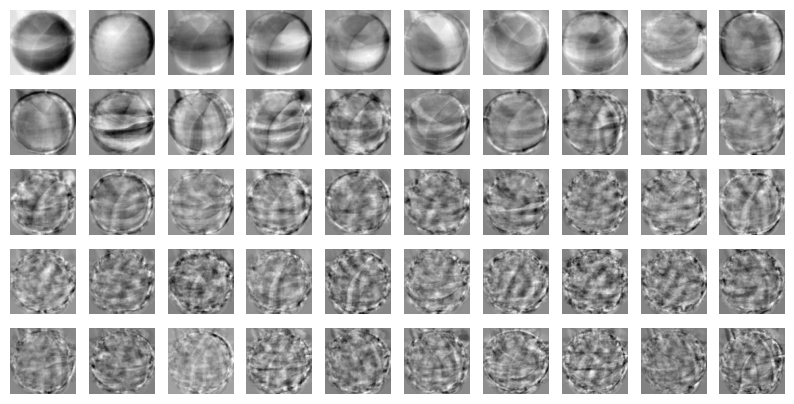

In [10]:
# 주성분 하나는 길이 10000인 벡터이므로
# 100×100으로 복원해 어떤 픽셀 패턴을 나타내는지 확인한다.
draw_fruits(pca.components_.reshape(-1, 100, 100))

![처음 50개의 주성분](assets/01_principal_components_50.png)

`components_.shape`은 `(50, 10000)`이다. 주성분 하나가 원본 픽셀 10000개에 대한 가중치로 구성되기 때문이다. 그림은 각 주성분이 강조하는 픽셀 패턴을 보여 준다.

## 3. 10000차원에서 50차원으로 투영

`transform()`은 원본 이미지를 주성분 축 위의 좌표로 바꾼다.

```text
원본 샘플: 픽셀값 10000개
PCA 변환: 주성분 좌표 50개
결과 크기: (300, 50)
```

> **이전 질문과 연결 — “주성분에 투영해서 특성의 개수를 줄인다는 게 무슨 뜻인가?”**  
> 이미지 한 장을 픽셀 10000개로 직접 설명하는 대신, 선택한 주성분 각각을 얼마나 포함하는지 나타내는 좌표 50개로 설명하는 것이다. 샘플 수 300개는 그대로이고, 샘플을 표현하는 숫자만 10000개에서 50개로 줄어든다.

In [11]:
# PCA 적용 전 데이터는 이미지 300장 × 픽셀 특성 10000개다.
print(fruits_2d.shape)

(300, 10000)


In [13]:
# 각 이미지를 50개의 주성분 좌표로 투영한다.
fruits_pca = pca.transform(fruits_2d)

# 샘플 수는 유지되고 특성 수만 10000개에서 50개로 줄어든다.
print(fruits_pca.shape)

(300, 50)


## 4. 역변환과 이미지 복원

`inverse_transform()`은 주성분 좌표 50개를 다시 픽셀 10000개로 바꾼다. 다만 사용하지 않은 나머지 주성분 정보는 사라졌으므로 원본과 완전히 같지는 않다.

In [14]:
# 50개의 주성분 좌표를 다시 원본 픽셀 공간으로 되돌린다.
# 잃어버린 정보가 있어 원본과 완전히 같지는 않다.
fruits_inverse = pca.inverse_transform(fruits_pca)
print(fruits_inverse.shape)

(300, 10000)


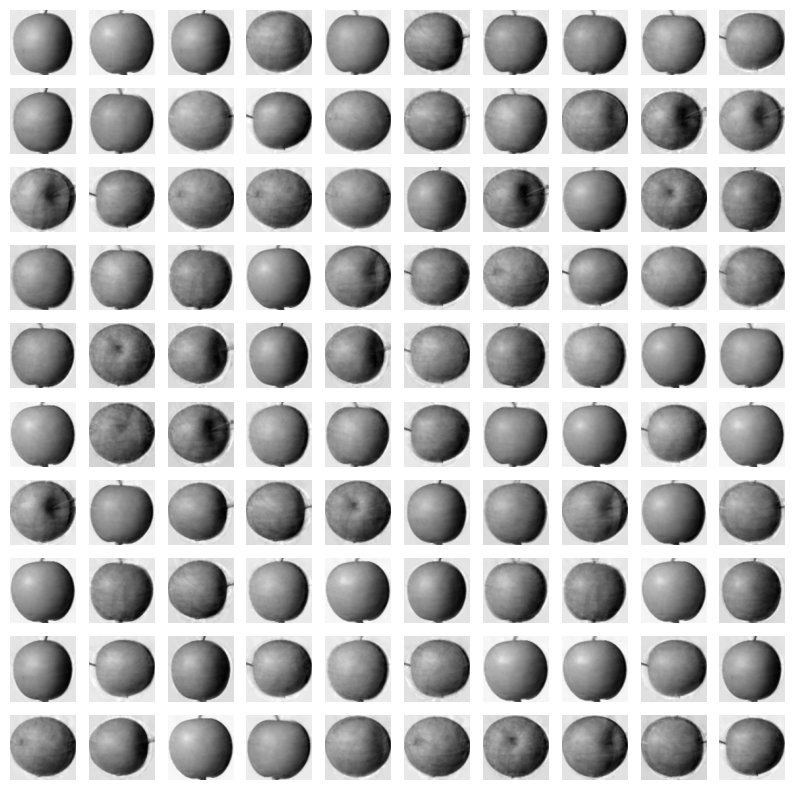

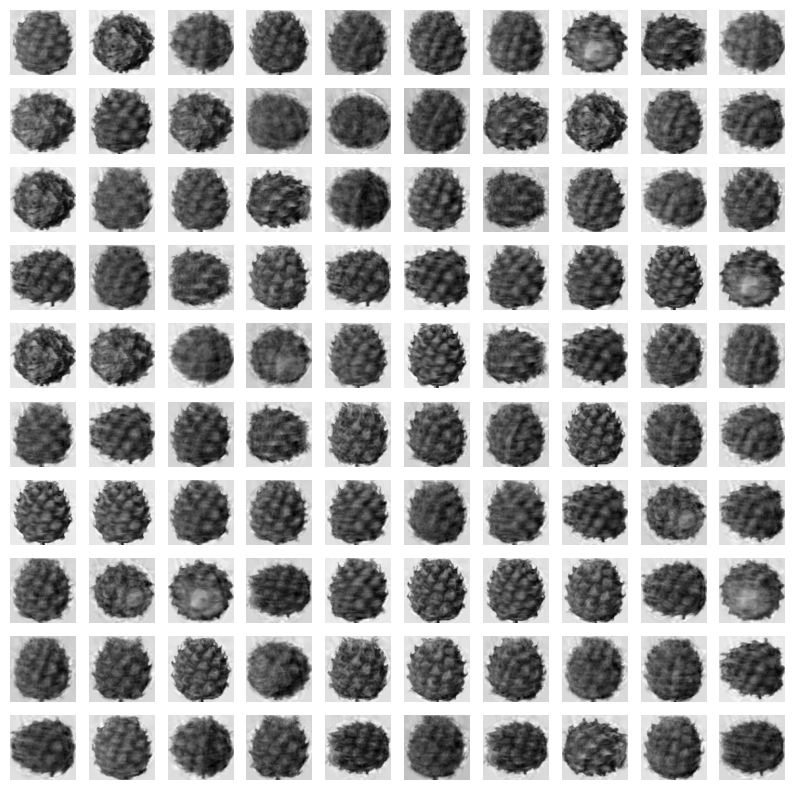

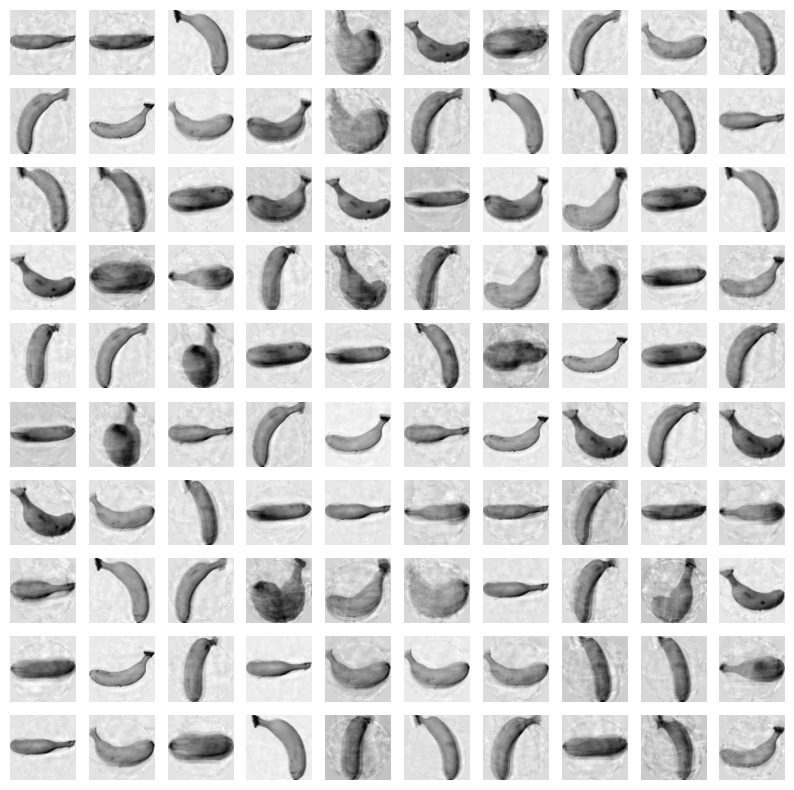

In [15]:
# 복원된 10000개 픽셀을 다시 100×100 이미지로 바꾼다.
fruits_reconstruct = fruits_inverse.reshape(-1, 100, 100)

# 사과·파인애플·바나나 복원 이미지를 각각 출력한다.
for start in [0, 100, 200]:
    draw_fruits(fruits_reconstruct[start:start + 100])
    print("\n")

![복원된 사과 이미지](assets/02_reconstructed_apples.png)

![복원된 파인애플 이미지](assets/03_reconstructed_pineapples.png)

![복원된 바나나 이미지](assets/04_reconstructed_bananas.png)

세부 픽셀 정보는 줄었지만 과일의 전체 형태는 유지된다. PCA가 샘플 차이를 많이 담는 방향을 우선 보존했기 때문이다.

## 5. 설명된 분산

50개 주성분이 보존한 전체 분산 비율은 약 `0.9216`, 즉 `92.16%`다.

- `explained_variance_ratio_[i]`: i번째 주성분이 설명하는 분산 비율
- 합계: 선택한 주성분들이 보존한 전체 정보량의 기준

In [16]:
# 선택한 50개 주성분이 원본 데이터 분산의 몇 %를 보존하는지 합산한다.
print(np.sum(pca.explained_variance_ratio_))

0.921606129720387


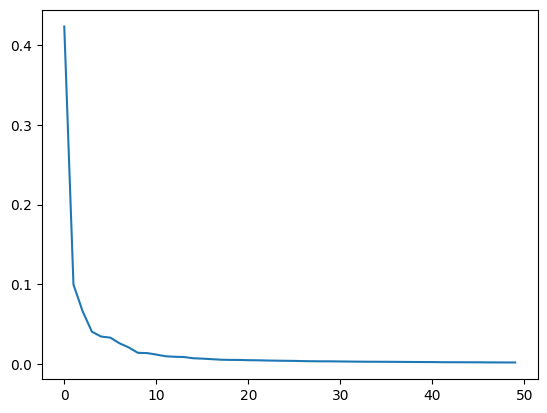

In [17]:
# 주성분 순서에 따른 설명된 분산 비율을 확인한다.
# 앞쪽 주성분일수록 더 많은 분산을 설명한다.
plt.plot(pca.explained_variance_ratio_)
plt.show()

![주성분별 설명된 분산 비율](assets/05_explained_variance_ratio.png)

앞쪽 주성분의 설명된 분산 비율이 크고 뒤로 갈수록 작아진다. 주성분은 분산을 많이 설명하는 순서로 정렬되기 때문이다.

> **이전 질문과 연결 — “분산이 큰 방향을 선택하면 왜 차원을 줄일 수 있나?”**  
> 샘플들이 거의 변하지 않는 방향은 서로를 구분하는 정보가 적다. 변화가 큰 방향부터 남기면 적은 축으로도 데이터의 주요 차이를 보존할 수 있다.

## 6. PCA 전후 로지스틱 회귀 비교

원본 10000차원과 PCA 50차원을 같은 로지스틱 회귀로 비교한다.

In [18]:
from sklearn.linear_model import LogisticRegression

# PCA 전후의 분류 성능과 학습 시간을 비교할 로지스틱 회귀 모델을 만든다.
lr = LogisticRegression()

In [20]:
# 원본 데이터의 저장 순서를 이용해 과일 종류 타깃을 만든다.
# 0: 사과, 1: 파인애플, 2: 바나나
target = np.array([0] * 100 + [1] * 100 + [2] * 100)

In [23]:
from sklearn.model_selection import cross_validate

# 원본 10000차원 데이터로 5-폴드 교차 검증을 수행한다.
scores = cross_validate(lr, fruits_2d, target)

# 평균 검증 정확도와 평균 학습 시간을 확인한다.
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.5289401054382324


In [24]:
# 50차원 PCA 데이터로 같은 로지스틱 회귀를 검증한다.
scores = cross_validate(lr, fruits_pca, target)

# 정확도를 유지하면서 학습 시간이 줄었는지 비교한다.
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.00917520523071289


| 입력 | 평균 검증 정확도 | 평균 학습 시간 |
|---|---:|---:|
| 원본 10000차원 | `0.9967` | `0.5289초` |
| PCA 50차원 | `0.9967` | `0.0092초` |

이 실행에서는 정확도를 유지하면서 평균 학습 시간이 크게 줄었다. PCA가 중복되거나 영향이 작은 방향을 제거해 모델이 처리할 특성 수를 줄였기 때문이다.

PCA는 정답 타깃을 사용하지 않고 입력 데이터의 분산만 분석하므로 비지도 학습 기반의 차원 축소 방법이다.

## 7. 설명된 분산 50%만 보존

`n_components=0.5`는 주성분을 50개로 고정한다는 뜻이 아니라, 전체 분산의 50% 이상을 보존하는 최소 개수를 자동으로 찾는 설정이다.

In [25]:
# 주성분 개수를 직접 정하지 않고
# 전체 분산의 50% 이상을 보존하는 최소 주성분 수를 찾는다.
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [26]:
# 분산 50%를 보존하는 데 필요한 주성분 수를 확인한다.
print(pca.n_components_)

2


In [27]:
# 원본 이미지를 선택된 주성분 좌표로 변환한다.
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [29]:
# 주성분 2개만 사용한 데이터로 로지스틱 회귀를 검증한다.
scores = cross_validate(lr, fruits_pca, target)

print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

# 원본 실행에서는 반복 횟수 한도에 도달했다는 수렴 경고가 발생했다.
# 차원이 적어도 최적화 조건에 따라 반복이 오래 걸릴 수 있다.

0.99
0.022046470642089845


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

필요한 주성분은 `2개`였고 데이터 크기는 `(300, 2)`가 됐다.

- 평균 검증 정확도: `0.99`
- 평균 학습 시간: `0.0220초`
- 원본 실행에서 로지스틱 회귀 수렴 경고 발생

주성분 수가 적다고 매번 측정 시간이 반드시 더 짧은 것은 아니다. 이 실행에서는 최적화가 반복 횟수 한도에 도달해 50차원 실행보다 시간이 길었다.

## 8. 2차원 PCA 데이터로 k-평균

주성분이 2개이면 각 샘플을 평면의 점 하나로 표시할 수 있다.

In [31]:
from sklearn.cluster import KMeans

# 2차원 PCA 데이터에서 k-평균으로 이미지 300장을 3개 군집으로 나눈다.
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

# 각 군집에 들어간 이미지 수를 확인한다.
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


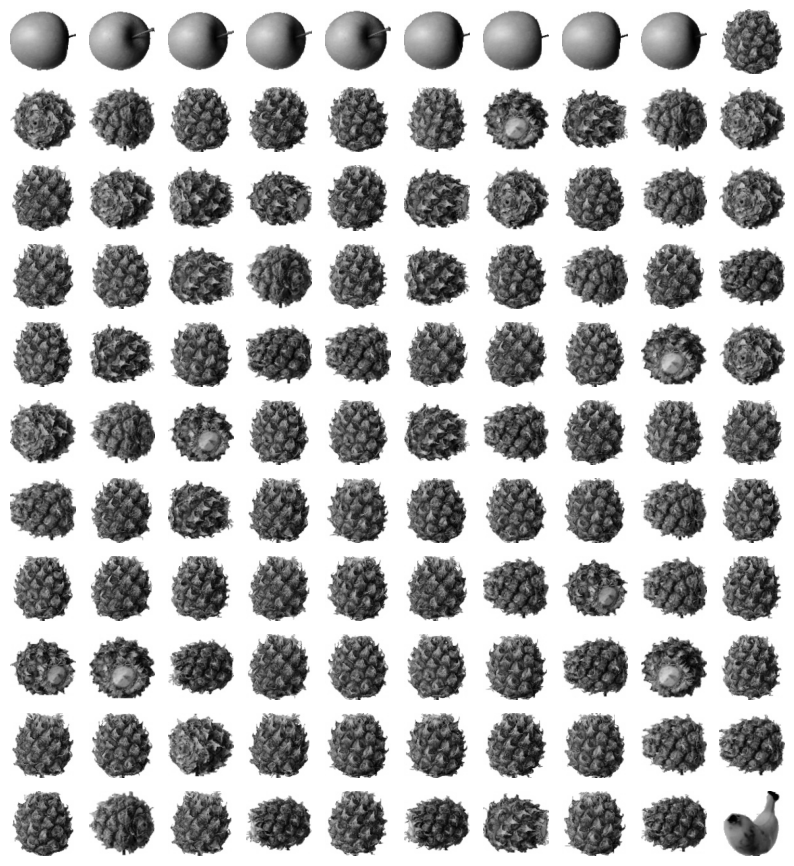

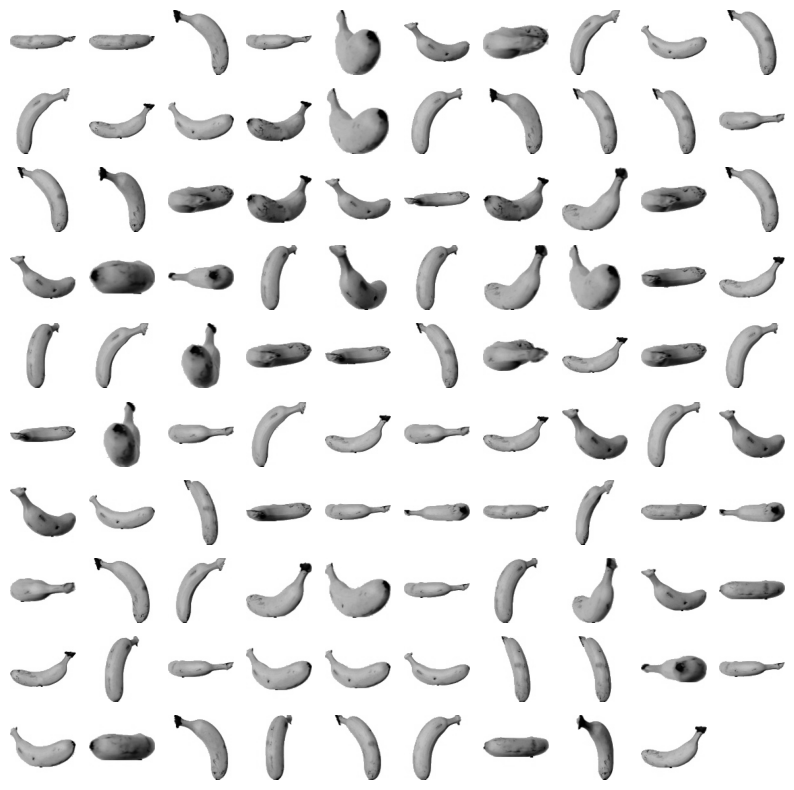

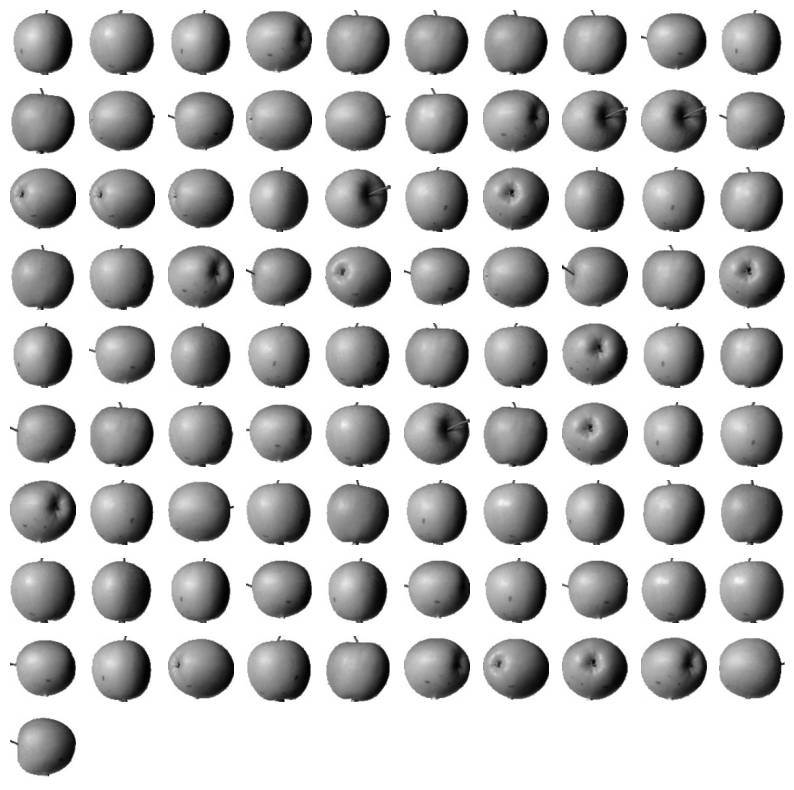

In [33]:
# PCA 2차원 공간에서 만들어진 각 군집의 원본 이미지를 확인한다.
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

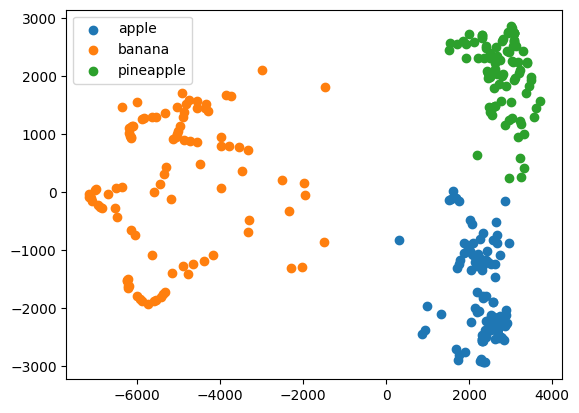

In [34]:
# 두 주성분을 x축과 y축으로 사용해 군집 분포를 산점도로 표시한다.
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:, 0], data[:, 1])

# 범례 문자열은 코드에 직접 입력한 것이며,
# 실제 군집 번호와 과일 이름의 대응은 자동으로 보장되지 않는다.
plt.legend(['apple', 'banana', 'pineapple'])
plt.show()

| 클러스터 번호 | 이미지 수 |
|---:|---:|
| `0` | `110` |
| `1` | `99` |
| `2` | `91` |

![2차원 PCA 클러스터 0](assets/06_pca_2d_cluster_0.png)

![2차원 PCA 클러스터 1](assets/07_pca_2d_cluster_1.png)

![2차원 PCA 클러스터 2](assets/08_pca_2d_cluster_2.png)

![처음 두 주성분의 군집 산점도](assets/09_pca_2d_scatter.png)

산점도의 축은 원본 픽셀 하나가 아니라 첫 번째·두 번째 주성분 좌표다. 코드의 범례 이름은 직접 입력한 문자열이므로 군집 번호와 실제 과일 이름이 자동으로 대응되는 것은 아니다.

## 9. 설명된 분산 99% 보존

이번에는 원본 분산의 99% 이상을 유지하는 최소 주성분 수를 사용한다.

In [35]:
# 이번에는 원본 분산의 99% 이상을 보존하는 최소 주성분 수를 찾는다.
pca = PCA(n_components=0.99)
pca.fit(fruits_2d)

PCA(n_components=0.99)

In [36]:
# 분산 99%를 보존하는 데 필요한 주성분 수를 확인한다.
print(pca.n_components_)

162


In [37]:
# 원본 10000차원 데이터를 162개의 주성분 좌표로 변환한다.
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 162)


In [38]:
# 162차원 PCA 데이터로 로지스틱 회귀를 교차 검증한다.
scores = cross_validate(lr, fruits_pca, target)

print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.0193603515625


In [39]:
from sklearn.cluster import KMeans

# 분산 99%를 보존한 PCA 데이터에서 k-평균 군집을 수행한다.
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))


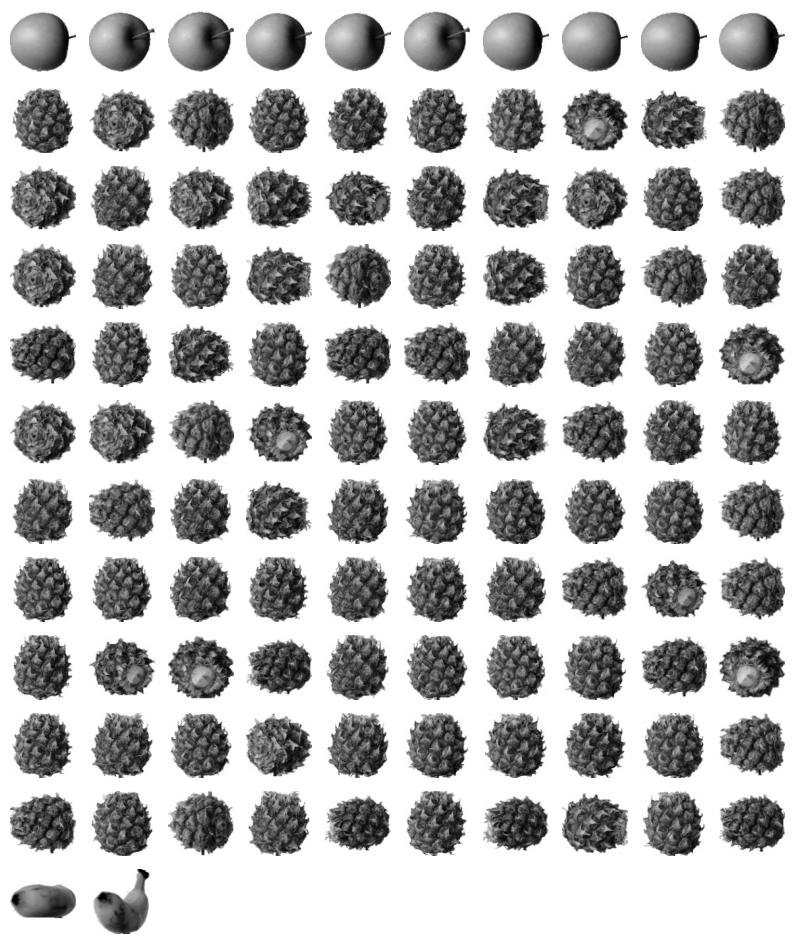

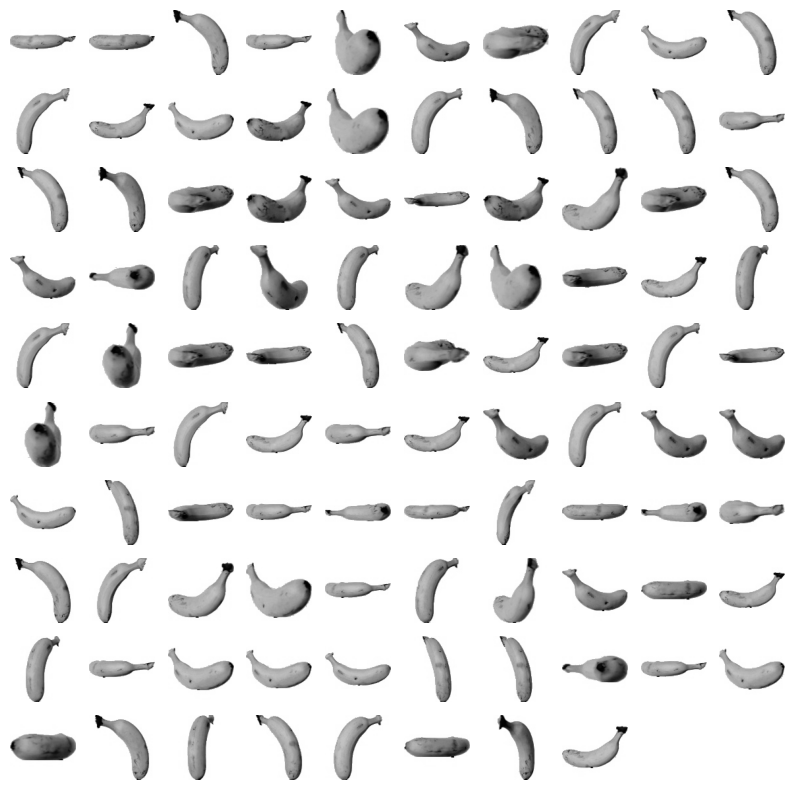

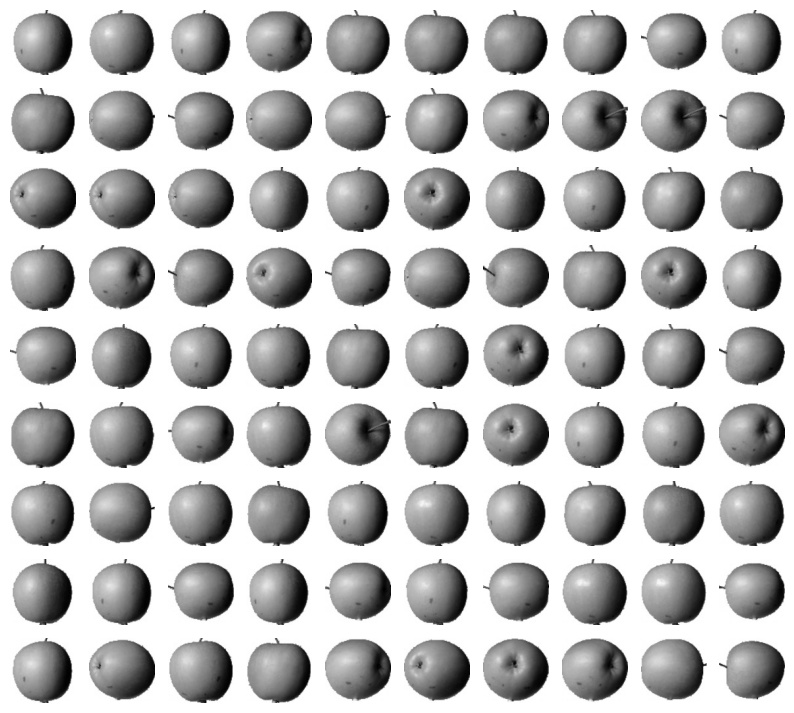

In [40]:
# 분산 99% PCA 데이터에서 얻은 각 군집의 원본 이미지를 확인한다.
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

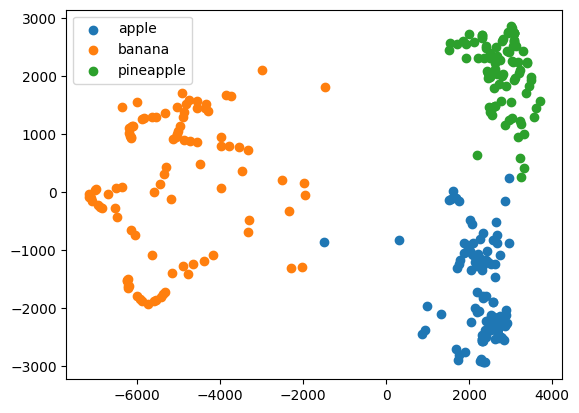

In [41]:
# 162개의 주성분 중 첫 번째와 두 번째 주성분만 산점도 축으로 사용한다.
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:, 0], data[:, 1])

# 범례 문자열은 직접 지정한 이름이며 군집 번호와 자동 매칭되지 않는다.
plt.legend(['apple', 'banana', 'pineapple'])
plt.show()

필요한 주성분은 `162개`였고 데이터 크기는 `(300, 162)`가 됐다.

### 로지스틱 회귀

| 입력 | 평균 검증 정확도 | 평균 학습 시간 |
|---|---:|---:|
| PCA 162차원 | `0.9967` | `0.0194초` |

원본 10000차원과 같은 정확도를 유지하면서 학습 시간은 줄었다.

### k-평균

| 클러스터 번호 | 이미지 수 |
|---:|---:|
| `0` | `112` |
| `1` | `98` |
| `2` | `90` |

![분산 99% PCA 클러스터 0](assets/10_pca_99_cluster_0.png)

![분산 99% PCA 클러스터 1](assets/11_pca_99_cluster_1.png)

![분산 99% PCA 클러스터 2](assets/12_pca_99_cluster_2.png)

![분산 99% PCA 데이터의 첫 두 주성분 산점도](assets/13_pca_99_scatter.png)

162차원 데이터 전체로 군집을 학습했고, 산점도는 시각화를 위해 그중 첫 두 주성분만 사용했다.

## 정리

```text
원본 이미지
→ 픽셀 특성 10000개

PCA 학습
→ 데이터 분산이 큰 방향부터 주성분 선택

PCA 변환
→ 원본 픽셀 좌표를 주성분 좌표로 변경
→ 샘플 수는 유지하고 특성 수만 감소

역변환
→ 선택한 주성분 정보로 원본 공간의 이미지 복원

설명된 분산
→ 선택한 주성분이 원본 데이터의 변화를 얼마나 보존하는지 표시
```

핵심은 PCA가 **원본 특성을 단순히 삭제하는 것이 아니라, 데이터의 주요 변화 방향을 나타내는 새로운 축으로 좌표계를 바꾸고 중요도가 낮은 축을 제외한다는 것**이다.